# Campus Resource & Student Success Intelligence System

## Business Intelligence & Predictive Analytics Project

**Author:** Thanusree

**Branch:** B.Tech – CSE with AI Specialization

### Project Objective

This project analyzes student academic performance, attendance, learning engagement, campus resource usage, and academic risk using Business Intelligence and Predictive Analytics techniques.

The project includes data preparation, exploratory data analysis, business insight generation, machine learning, model evaluation, and student risk prediction.

In [3]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully!")

All libraries imported successfully!


## 1. Dataset Loading

The project uses a synthetic student dataset containing academic, attendance, engagement, campus-resource, and student-development information for 1,000 students.

In [4]:
# Load the student dataset

data_path = "data/student_success_data.csv"

df = pd.read_csv(data_path)

print("Dataset loaded successfully!")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully!
Rows: 1000
Columns: 21


### Dataset Preview

The first few records are displayed to understand the structure and contents of the dataset.

In [5]:
# Display the first five records

df.head()

,Student_ID,Branch,Year,Gender,Attendance,Previous_CGPA,Internal_Marks,Assignment_Score,Study_Hours,LMS_Activity,...,Lab_Usage,Certifications,Projects,Hackathons,Internships,Commute_Time,Backlogs,Final_CGPA,Academic_Status,Risk_Level
0,STU0001,EEE,3rd Year,Male,73.16,7.05,78.75,83.95,4.22,83.66,...,53.57,4,2,0,0,27.70,1,7.22,Needs Attention,Medium Risk
1,STU0002,Mechanical,2nd Year,Male,87.10,7.37,67.35,85.07,1.77,64.00,...,75.82,4,5,0,3,60.23,0,6.97,Needs Attention,Low Risk
2,STU0003,ECE,3rd Year,Male,77.89,6.26,68.43,71.11,4.41,39.87,...,73.36,3,2,0,1,65.10,0,6.52,Needs Attention,Medium Risk
3,STU0004,Mechanical,3rd Year,Female,78.83,8.89,57.88,77.44,2.50,43.55,...,61.32,3,3,0,1,60.31,0,7.60,Good Standing,Low Risk
4,STU0005,Mechanical,4th Year,Male,79.73,7.56,71.82,80.89,6.24,68.92,...,68.76,1,1,1,2,25.17,0,7.99,Good Standing,Low Risk


### Dataset Information

The dataset contains student-level records covering academic performance, attendance, learning engagement, campus resource usage, skill development, and academic risk.

In [6]:
# Display dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Student_ID        1000 non-null   str    
 1   Branch            1000 non-null   str    
 2   Year              1000 non-null   str    
 3   Gender            1000 non-null   str    
 4   Attendance        1000 non-null   float64
 5   Previous_CGPA     1000 non-null   float64
 6   Internal_Marks    1000 non-null   float64
 7   Assignment_Score  1000 non-null   float64
 8   Study_Hours       1000 non-null   float64
 9   LMS_Activity      1000 non-null   float64
 10  Library_Visits    1000 non-null   int64  
 11  Lab_Usage         1000 non-null   float64
 12  Certifications    1000 non-null   int64  
 13  Projects          1000 non-null   int64  
 14  Hackathons        1000 non-null   int64  
 15  Internships       1000 non-null   int64  
 16  Commute_Time      1000 non-null   float64
 17  Backlog

### Data Quality Check

Before performing analysis, the dataset is checked for missing values and duplicate records to ensure data quality.

In [7]:
# Check missing values

missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values)

print("\nTotal Missing Values:", missing_values.sum())

# Check duplicate rows

duplicate_rows = df.duplicated().sum()

print("\nDuplicate Rows:", duplicate_rows)

# Check duplicate Student IDs

duplicate_ids = df["Student_ID"].duplicated().sum()

print("Duplicate Student IDs:", duplicate_ids)

Missing Values:
Student_ID          0
Branch              0
Year                0
Gender              0
Attendance          0
Previous_CGPA       0
Internal_Marks      0
Assignment_Score    0
Study_Hours         0
LMS_Activity        0
Library_Visits      0
Lab_Usage           0
Certifications      0
Projects            0
Hackathons          0
Internships         0
Commute_Time        0
Backlogs            0
Final_CGPA          0
Academic_Status     0
Risk_Level          0
dtype: int64

Total Missing Values: 0

Duplicate Rows: 0
Duplicate Student IDs: 0


### Statistical Summary

A statistical summary is used to understand the central tendency and spread of the numerical variables in the dataset.

In [8]:
# Display statistical summary of numerical variables

df.describe().round(2)

,Attendance,Previous_CGPA,Internal_Marks,Assignment_Score,Study_Hours,LMS_Activity,Library_Visits,Lab_Usage,Certifications,Projects,Hackathons,Internships,Commute_Time,Backlogs,Final_CGPA
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,80.25,7.51,71.69,74.20,4.54,67.92,5.03,69.97,1.95,2.00,0.98,0.97,41.35,0.38,7.33
std,9.55,0.90,11.96,11.48,1.48,15.69,2.25,14.65,1.39,1.33,1.00,0.95,17.24,0.62,0.62
min,50.00,5.00,40.00,40.00,1.00,20.00,0.00,30.84,0.00,0.00,0.00,0.00,5.00,0.00,5.26
25%,73.66,6.89,63.42,66.12,3.54,57.16,3.00,59.61,1.00,1.00,0.00,0.00,29.30,0.00,6.92
50%,80.47,7.52,71.83,74.04,4.55,68.50,5.00,70.03,2.00,2.00,1.00,1.00,41.55,0.00,7.35
75%,86.84,8.16,80.19,82.14,5.58,78.59,6.00,80.20,3.00,3.00,2.00,2.00,53.98,1.00,7.77
max,100.00,9.80,100.00,100.00,8.70,100.00,15.00,100.00,7.00,6.00,4.00,3.00,90.74,4.00,9.05


### Academic Status Distribution

The distribution of academic status is analyzed to understand how students are performing overall and how many students require academic attention.

In [9]:
# Analyze academic status distribution

academic_status_counts = df["Academic_Status"].value_counts()

print("Academic Status Distribution:")
print(academic_status_counts)

Academic Status Distribution:
Academic_Status
Needs Attention    555
Good Standing      422
At Risk             23
Name: count, dtype: int64


### Academic Status Visualization

A bar chart is used to compare the number of students in each academic status category.

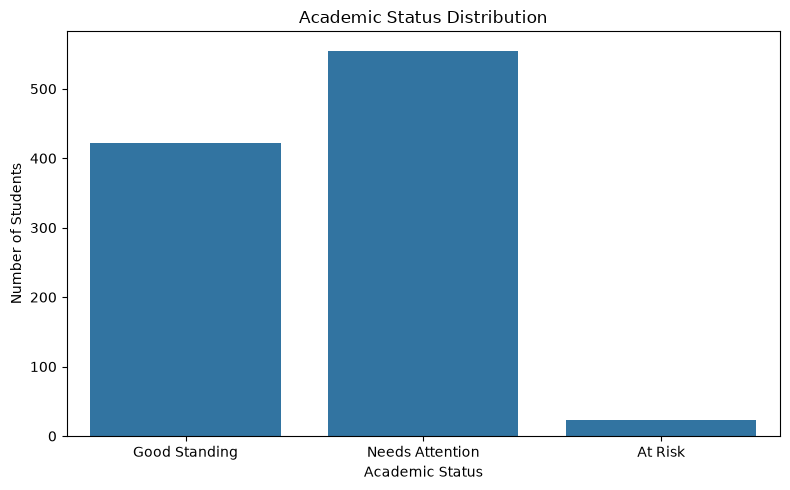

In [10]:
# Visualize academic status distribution

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Academic_Status",
    order=["Good Standing", "Needs Attention", "At Risk"]
)

plt.title("Academic Status Distribution")
plt.xlabel("Academic Status")
plt.ylabel("Number of Students")

plt.tight_layout()
plt.show()

### Risk Level Distribution

The distribution of student risk levels is analyzed to understand the proportion of students classified as Low Risk, Medium Risk, and High Risk.

In [11]:
# Analyze risk level distribution

risk_counts = df["Risk_Level"].value_counts()

print("Risk Level Distribution:")
print(risk_counts)

Risk Level Distribution:
Risk_Level
Low Risk       650
Medium Risk    230
High Risk      120
Name: count, dtype: int64


### Risk Level Visualization

A bar chart is used to compare the number of students across different risk levels.

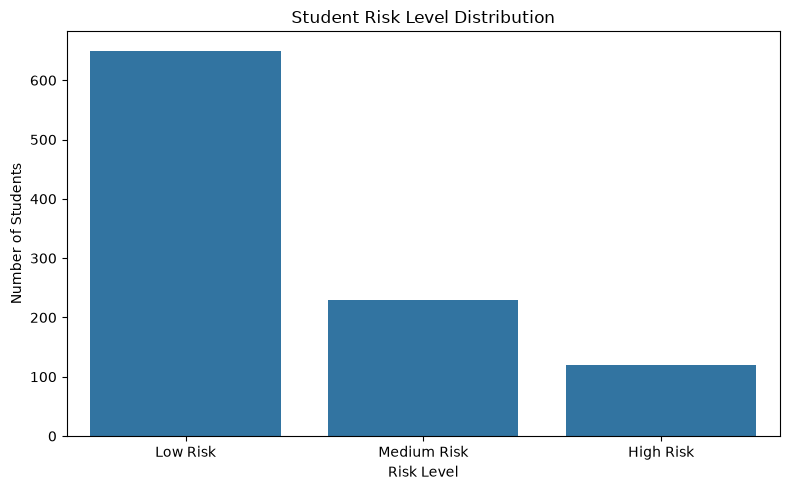

In [12]:
# Visualize risk level distribution

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Risk_Level",
    order=["Low Risk", "Medium Risk", "High Risk"]
)

plt.title("Student Risk Level Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Students")

plt.tight_layout()
plt.show()

### Branch-wise Academic Performance

The average Final CGPA is compared across different academic branches to identify differences in academic performance.

In [13]:
# Calculate average CGPA by branch

branch_performance = (
    df.groupby("Branch")
    .agg(
        Students=("Student_ID", "count"),
        Average_CGPA=("Final_CGPA", "mean"),
        Average_Attendance=("Attendance", "mean")
    )
    .round(2)
    .sort_values("Average_CGPA", ascending=False)
)

branch_performance

,Students,Average_CGPA,Average_Attendance
Branch,,,
Mechanical,172,7.42,80.99
Civil,155,7.33,80.15
EEE,174,7.33,80.07
ECE,154,7.31,79.14
CSE,181,7.30,80.78
CSE-AI,164,7.27,80.21


### Branch Performance Visualization

A bar chart is used to compare the average Final CGPA across different academic branches.

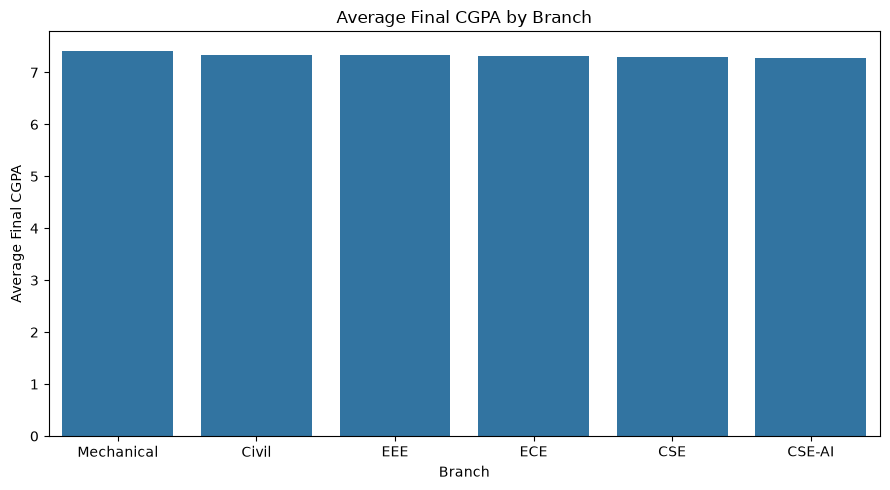

In [14]:
# Visualize average CGPA by branch

plt.figure(figsize=(9, 5))

sns.barplot(
    data=branch_performance.reset_index(),
    x="Branch",
    y="Average_CGPA"
)

plt.title("Average Final CGPA by Branch")
plt.xlabel("Branch")
plt.ylabel("Average Final CGPA")

plt.tight_layout()
plt.show()

### Attendance vs Final CGPA

The relationship between student attendance and Final CGPA is analyzed using a scatter plot. A trendline is added to observe the overall direction of the relationship.

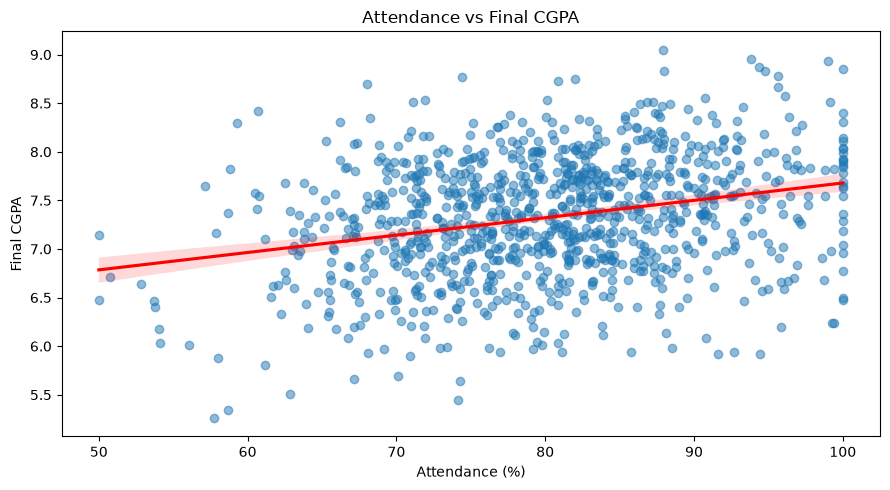

In [15]:
# Analyze the relationship between attendance and Final CGPA

plt.figure(figsize=(9, 5))

sns.regplot(
    data=df,
    x="Attendance",
    y="Final_CGPA",
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red"}
)

plt.title("Attendance vs Final CGPA")
plt.xlabel("Attendance (%)")
plt.ylabel("Final CGPA")

plt.tight_layout()
plt.show()

### Attendance Correlation with Final CGPA

The correlation coefficient is calculated to measure the strength and direction of the relationship between attendance and Final CGPA.

In [16]:
# Calculate correlation between Attendance and Final CGPA

attendance_correlation = df["Attendance"].corr(df["Final_CGPA"])

print("Correlation between Attendance and Final CGPA:")
print(round(attendance_correlation, 3))

Correlation between Attendance and Final CGPA:
0.276


### Backlogs vs Final CGPA

The relationship between the number of backlogs and Final CGPA is analyzed to understand how academic backlogs are associated with student performance.

In [17]:
# Calculate average Final CGPA by number of backlogs

backlog_performance = (
    df.groupby("Backlogs")
    .agg(
        Students=("Student_ID", "count"),
        Average_CGPA=("Final_CGPA", "mean")
    )
    .round(2)
)

backlog_performance

,Students,Average_CGPA
Backlogs,,
0,687,7.49
1,248,7.04
2,61,6.71
3,3,6.57
4,1,6.81


### Backlogs vs Final CGPA Visualization

A bar chart is used to compare the average Final CGPA across different numbers of backlogs.

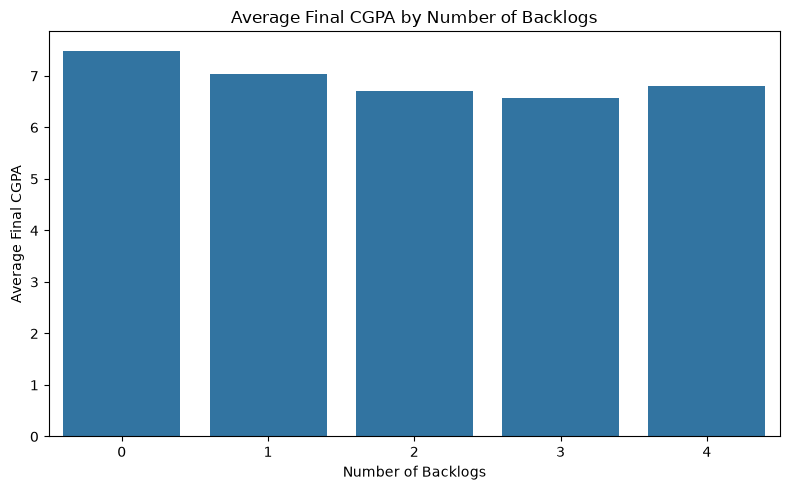

In [18]:
# Visualize average Final CGPA by number of backlogs

plt.figure(figsize=(8, 5))

sns.barplot(
    data=backlog_performance.reset_index(),
    x="Backlogs",
    y="Average_CGPA"
)

plt.title("Average Final CGPA by Number of Backlogs")
plt.xlabel("Number of Backlogs")
plt.ylabel("Average Final CGPA")

plt.tight_layout()
plt.show()

### LMS Activity vs Final CGPA

The relationship between LMS activity and Final CGPA is analyzed to understand whether student online learning engagement is associated with academic performance.

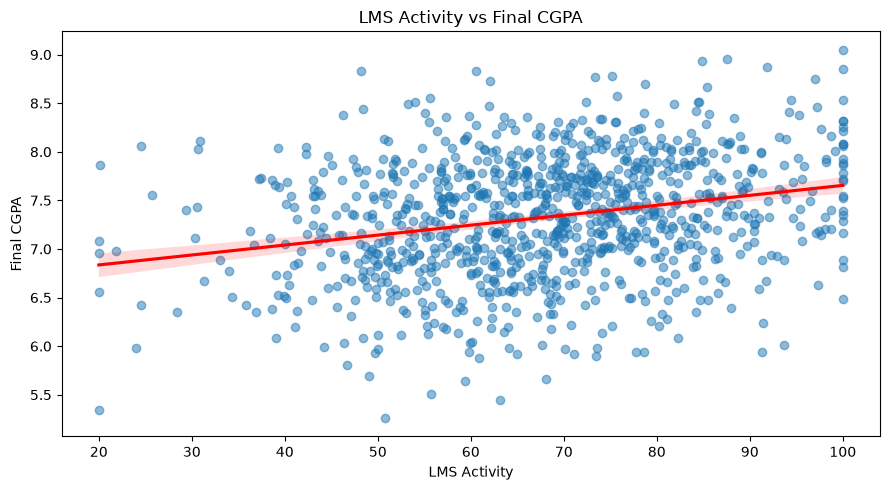

In [19]:
# Analyze LMS Activity vs Final CGPA

plt.figure(figsize=(9, 5))

sns.regplot(
    data=df,
    x="LMS_Activity",
    y="Final_CGPA",
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red"}
)

plt.title("LMS Activity vs Final CGPA")
plt.xlabel("LMS Activity")
plt.ylabel("Final CGPA")

plt.tight_layout()
plt.show()

### LMS Activity Correlation with Final CGPA

The correlation coefficient is calculated to measure the strength and direction of the relationship between LMS activity and Final CGPA.

In [20]:
# Calculate correlation between LMS Activity and Final CGPA

lms_correlation = df["LMS_Activity"].corr(df["Final_CGPA"])

print("Correlation between LMS Activity and Final CGPA:")
print(round(lms_correlation, 3))

Correlation between LMS Activity and Final CGPA:
0.26


### Campus Resource Usage Analysis

The average usage of learning resources and student development activities is analyzed to understand overall student engagement with campus and academic resources.

In [21]:
# Calculate average campus resource usage

resource_usage = pd.DataFrame({
    "Resource": [
        "LMS Activity",
        "Library Visits",
        "Lab Usage",
        "Certifications",
        "Projects",
        "Hackathons",
        "Internships"
    ],
    "Average_Usage": [
        df["LMS_Activity"].mean(),
        df["Library_Visits"].mean(),
        df["Lab_Usage"].mean(),
        df["Certifications"].mean(),
        df["Projects"].mean(),
        df["Hackathons"].mean(),
        df["Internships"].mean()
    ]
})

resource_usage["Average_Usage"] = resource_usage["Average_Usage"].round(2)

resource_usage

,Resource,Average_Usage
0,LMS Activity,67.92
1,Library Visits,5.03
2,Lab Usage,69.97
3,Certifications,1.95
4,Projects,2.00
5,Hackathons,0.98
6,Internships,0.97


### Resource Usage Visualization

A bar chart is used to compare the average usage of different academic, campus, and student-development resources.

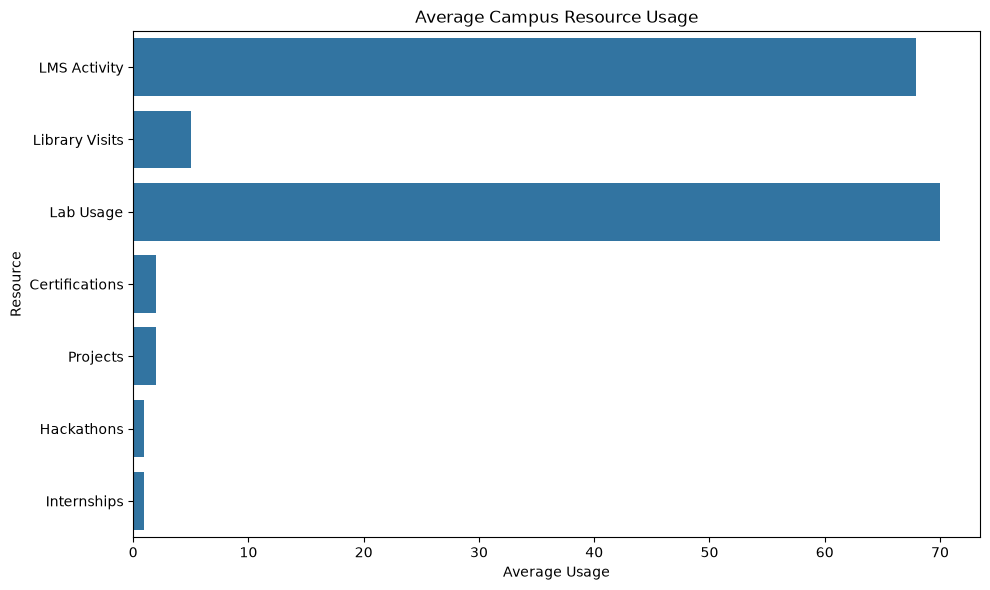

In [22]:
# Visualize average resource usage

plt.figure(figsize=(10, 6))

sns.barplot(
    data=resource_usage,
    x="Average_Usage",
    y="Resource"
)

plt.title("Average Campus Resource Usage")
plt.xlabel("Average Usage")
plt.ylabel("Resource")

plt.tight_layout()
plt.show()

### Correlation Analysis

Correlation analysis is used to examine the strength and direction of relationships between numerical variables and Final CGPA.

In [23]:
# Calculate correlations with Final CGPA

correlation_with_cgpa = (
    df.select_dtypes(include="number")
    .corr()["Final_CGPA"]
    .sort_values(ascending=False)
)

correlation_with_cgpa

Final_CGPA          1.000000
Previous_CGPA       0.715789
Internal_Marks      0.286253
Attendance          0.276292
LMS_Activity        0.259852
Assignment_Score    0.186333
Study_Hours         0.166216
Projects            0.126702
Certifications      0.036052
Lab_Usage           0.015364
Internships         0.014489
Hackathons          0.010101
Library_Visits      0.000097
Commute_Time       -0.093155
Backlogs           -0.400826
Name: Final_CGPA, dtype: float64

### Correlation Heatmap

A correlation heatmap is used to visually examine relationships among numerical variables in the student dataset. Values closer to 1 indicate a stronger positive association, while values closer to -1 indicate a stronger negative association.

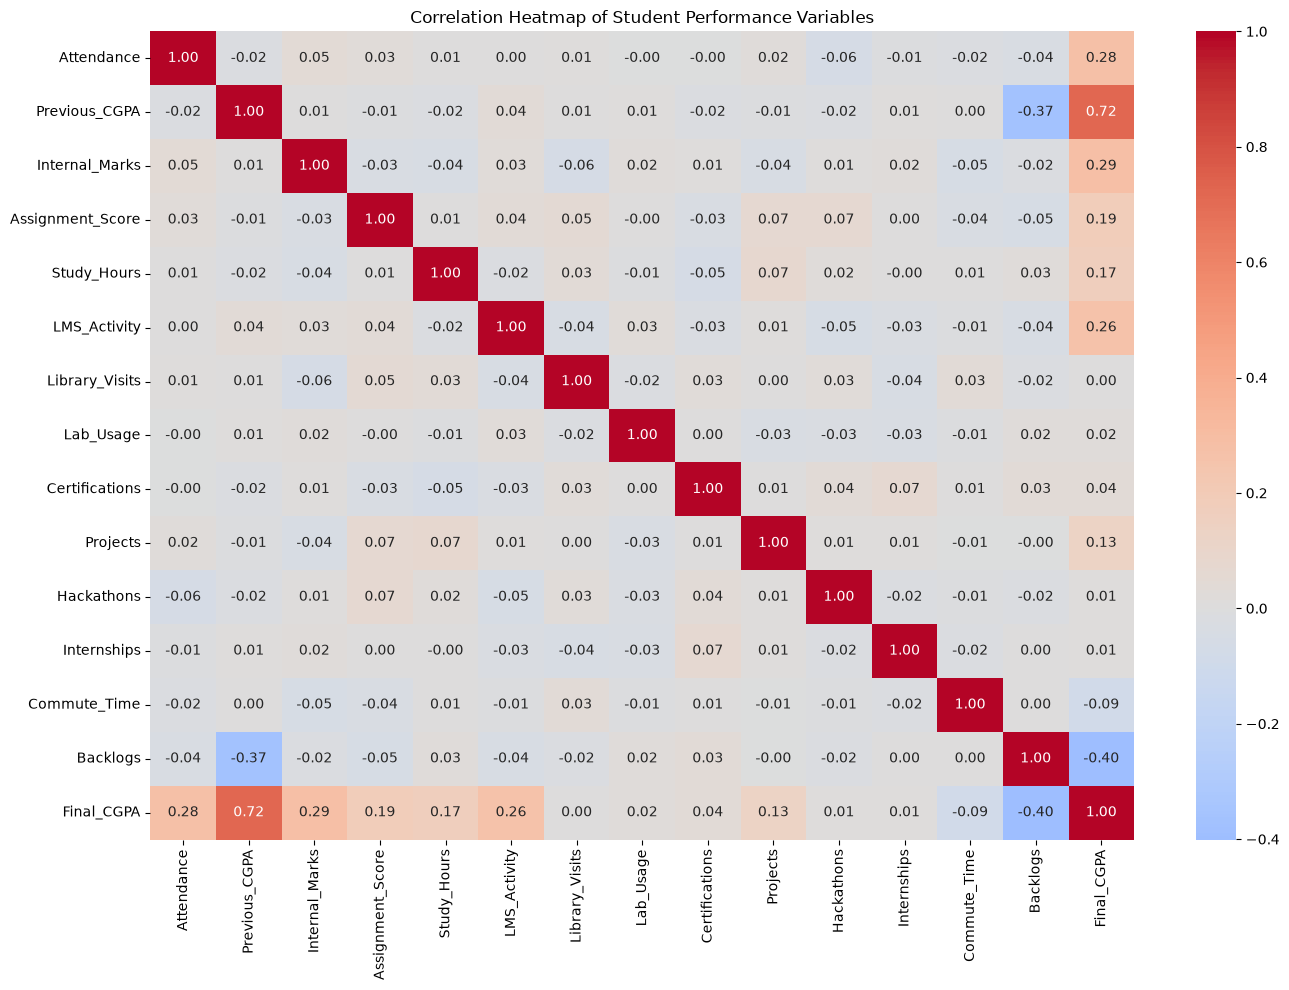

In [24]:
# Create correlation heatmap

numeric_df = df.select_dtypes(include="number")

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Student Performance Variables")
plt.tight_layout()
plt.show()

## 2. Business Insights

The exploratory analysis is converted into actionable business insights by identifying important patterns in academic performance, attendance, engagement, and academic risk.

### Insight 1 — Attendance and Academic Performance

Students with higher attendance show higher average Final CGPA in this dataset. Students with attendance above 85% have the highest average CGPA, while students below 60% have the lowest average CGPA.

This represents an association in the synthetic dataset and does not establish that attendance directly causes higher academic performance.

In [25]:
# Compare average CGPA across attendance groups

attendance_groups = pd.cut(
    df["Attendance"],
    bins=[0, 60, 75, 85, 100],
    labels=["Below 60%", "60-75%", "75-85%", "Above 85%"]
)

attendance_analysis = (
    df.assign(Attendance_Group=attendance_groups)
    .groupby("Attendance_Group", observed=False)
    .agg(
        Students=("Student_ID", "count"),
        Average_CGPA=("Final_CGPA", "mean")
    )
    .round(2)
)

attendance_analysis

,Students,Average_CGPA
Attendance_Group,,
Below 60%,17,6.64
60-75%,282,7.15
75-85%,393,7.32
Above 85%,308,7.53


### Insight 2 — Backlogs and Academic Performance

Students with no backlogs have the highest average Final CGPA in the dataset. Average CGPA generally decreases as the number of backlogs increases.

This indicates an association between academic backlogs and lower academic performance in the synthetic dataset.

In [26]:
# Compare average CGPA across backlog groups

backlog_insight = (
    df.groupby("Backlogs")
    .agg(
        Students=("Student_ID", "count"),
        Average_CGPA=("Final_CGPA", "mean")
    )
    .round(2)
)

backlog_insight

,Students,Average_CGPA
Backlogs,,
0,687,7.49
1,248,7.04
2,61,6.71
3,3,6.57
4,1,6.81


### Insight 3 — LMS Engagement and Academic Performance

Students with higher LMS activity show higher average Final CGPA in this dataset. This suggests a positive association between online learning engagement and academic performance.

The relationship is observational and does not establish that LMS activity directly causes higher CGPA.

In [27]:
# Create LMS activity groups

lms_groups = pd.cut(
    df["LMS_Activity"],
    bins=[0, 50, 70, 85, 100],
    labels=["Low", "Medium", "High", "Very High"]
)

lms_insight = (
    df.assign(LMS_Group=lms_groups)
    .groupby("LMS_Group", observed=False)
    .agg(
        Students=("Student_ID", "count"),
        Average_CGPA=("Final_CGPA", "mean")
    )
    .round(2)
)

lms_insight

,Students,Average_CGPA
LMS_Group,,
Low,128,7.08
Medium,421,7.23
High,313,7.44
Very High,138,7.58


### Insight 4 — High-Risk Student Profile

The characteristics of High-Risk students are compared with the overall student population. This helps identify patterns that may be useful for designing academic support interventions.

In [28]:
# Compare High-Risk students with the overall student population

high_risk = df[df["Risk_Level"] == "High Risk"]

high_risk_profile = pd.DataFrame({
    "Metric": [
        "Students",
        "Average Attendance",
        "Average Previous CGPA",
        "Average Final CGPA",
        "Average Internal Marks",
        "Average Assignment Score",
        "Average LMS Activity",
        "Average Study Hours",
        "Average Backlogs"
    ],
    "High_Risk": [
        len(high_risk),
        high_risk["Attendance"].mean(),
        high_risk["Previous_CGPA"].mean(),
        high_risk["Final_CGPA"].mean(),
        high_risk["Internal_Marks"].mean(),
        high_risk["Assignment_Score"].mean(),
        high_risk["LMS_Activity"].mean(),
        high_risk["Study_Hours"].mean(),
        high_risk["Backlogs"].mean()
    ],
    "Overall": [
        len(df),
        df["Attendance"].mean(),
        df["Previous_CGPA"].mean(),
        df["Final_CGPA"].mean(),
        df["Internal_Marks"].mean(),
        df["Assignment_Score"].mean(),
        df["LMS_Activity"].mean(),
        df["Study_Hours"].mean(),
        df["Backlogs"].mean()
    ]
})

high_risk_profile["High_Risk"] = high_risk_profile["High_Risk"].round(2)
high_risk_profile["Overall"] = high_risk_profile["Overall"].round(2)

high_risk_profile

,Metric,High_Risk,Overall
0,Students,120.00,1000.00
1,Average Attendance,76.79,80.25
2,Average Previous CGPA,6.34,7.51
3,Average Final CGPA,6.49,7.33
4,Average Internal Marks,69.20,71.69
5,Average Assignment Score,72.91,74.20
6,Average LMS Activity,64.54,67.92
7,Average Study Hours,4.15,4.54
8,Average Backlogs,1.46,0.38


### High-Risk Students by Branch

The number and percentage of High-Risk students are analyzed across branches to identify where academic support needs are more concentrated.

In [29]:
# Calculate High-Risk students by branch

high_risk_by_branch = (
    df.groupby("Branch")
    .agg(
        Students=("Student_ID", "count"),
        High_Risk_Students=("Risk_Level", lambda x: (x == "High Risk").sum())
    )
)

high_risk_by_branch["High_Risk_Percentage"] = (
    high_risk_by_branch["High_Risk_Students"]
    / high_risk_by_branch["Students"]
    * 100
).round(2)

high_risk_by_branch = high_risk_by_branch.sort_values(
    "High_Risk_Percentage",
    ascending=False
)

high_risk_by_branch

,Students,High_Risk_Students,High_Risk_Percentage
Branch,,,
CSE-AI,164,24,14.63
ECE,154,21,13.64
EEE,174,22,12.64
Civil,155,18,11.61
CSE,181,19,10.50
Mechanical,172,16,9.30


### High-Risk Students by Branch Visualization

A bar chart is used to compare the percentage of High-Risk students across academic branches.

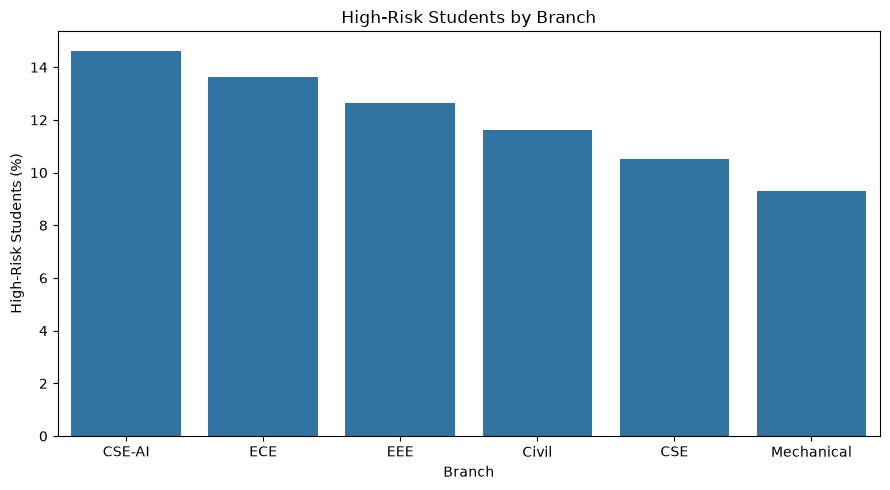

In [30]:
# Visualize High-Risk percentage by branch

plt.figure(figsize=(9, 5))

sns.barplot(
    data=high_risk_by_branch.reset_index(),
    x="Branch",
    y="High_Risk_Percentage"
)

plt.title("High-Risk Students by Branch")
plt.xlabel("Branch")
plt.ylabel("High-Risk Students (%)")

plt.tight_layout()
plt.show()

## 3. Predictive Analytics & Machine Learning

A Random Forest classification model is used to predict student academic risk levels. The target variable is Risk_Level, with three categories: Low Risk, Medium Risk, and High Risk.

Final_CGPA and Academic_Status are excluded from the model features to avoid target leakage because they are outcomes related to the student's academic performance.

In [31]:
# Prepare features and target variable

features = [
    "Attendance",
    "Previous_CGPA",
    "Internal_Marks",
    "Assignment_Score",
    "Study_Hours",
    "LMS_Activity",
    "Library_Visits",
    "Lab_Usage",
    "Certifications",
    "Projects",
    "Hackathons",
    "Internships",
    "Commute_Time",
    "Backlogs"
]

target = "Risk_Level"

X = df[features]
y = df[target]

print("Features used for prediction:")
print(features)

print("\nTarget variable:")
print(target)

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

Features used for prediction:
['Attendance', 'Previous_CGPA', 'Internal_Marks', 'Assignment_Score', 'Study_Hours', 'LMS_Activity', 'Library_Visits', 'Lab_Usage', 'Certifications', 'Projects', 'Hackathons', 'Internships', 'Commute_Time', 'Backlogs']

Target variable:
Risk_Level

Feature shape: (1000, 14)
Target shape: (1000,)


### Train-Test Split

The dataset is divided into training and testing sets. The training data is used to build the model, while the testing data is used to evaluate how well the model performs on unseen student records.

In [32]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining risk distribution:")
print(y_train.value_counts())

print("\nTesting risk distribution:")
print(y_test.value_counts())

Training samples: 800
Testing samples: 200

Training risk distribution:
Risk_Level
Low Risk       520
Medium Risk    184
High Risk       96
Name: count, dtype: int64

Testing risk distribution:
Risk_Level
Low Risk       130
Medium Risk     46
High Risk       24
Name: count, dtype: int64


### Random Forest Classification Model

A Random Forest Classifier is trained to predict whether a student belongs to the Low Risk, Medium Risk, or High Risk category.

In [33]:
# Create and train the Random Forest model

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

0.01s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.


Random Forest model trained successfully!


### Model Predictions

The trained Random Forest model is used to predict the Risk_Level of students in the testing dataset.

In [34]:
# Make predictions on the test dataset

y_pred = model.predict(X_test)

print("Predictions generated successfully!")
print("Number of predictions:", len(y_pred))

print("\nPredicted Risk Distribution:")
print(pd.Series(y_pred).value_counts())

Predictions generated successfully!
Number of predictions: 200

Predicted Risk Distribution:
Low Risk       122
Medium Risk     51
High Risk       27
Name: count, dtype: int64


### Model Evaluation — Accuracy and F1 Score

Accuracy measures the overall percentage of correct predictions. Macro F1 gives equal importance to each risk category and is useful when evaluating multiple classes.

In [35]:
# Calculate model evaluation metrics

accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")

print("Model Performance")
print("-" * 30)
print(f"Accuracy : {accuracy:.2%}")
print(f"Macro F1 : {macro_f1:.2%}")
print(f"Test Students : {len(y_test)}")

Model Performance
------------------------------
Accuracy : 88.50%
Macro F1 : 84.36%
Test Students : 200


### Classification Report

The classification report provides precision, recall, and F1-score for each student risk category. This helps evaluate how well the model performs for each class rather than relying only on overall accuracy.

In [36]:
# Generate classification report

report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

classification_report_df = pd.DataFrame(report).transpose()

classification_report_df.round(3)

,precision,recall,f1-score,support
High Risk,0.778,0.875,0.824,24.000
Low Risk,0.975,0.915,0.944,130.000
Medium Risk,0.725,0.804,0.763,46.000
accuracy,0.885,0.885,0.885,0.885
macro avg,0.826,0.865,0.844,200.000
weighted avg,0.894,0.885,0.888,200.000


### Confusion Matrix

A confusion matrix compares the actual risk levels with the risk levels predicted by the Random Forest model. It helps identify correct predictions and misclassifications for Low Risk, Medium Risk, and High Risk students.

In [37]:
# Calculate and display the confusion matrix

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

cm_df = pd.DataFrame(
    cm,
    index=["Actual Low Risk", "Actual Medium Risk", "Actual High Risk"],
    columns=["Predicted Low Risk", "Predicted Medium Risk", "Predicted High Risk"]
)

cm_df

,Predicted Low Risk,Predicted Medium Risk,Predicted High Risk
Actual Low Risk,119,11,0
Actual Medium Risk,3,37,6
Actual High Risk,0,3,21


### Confusion Matrix Visualization

A heatmap is used to visually represent the confusion matrix and identify correct predictions and misclassifications across the three student risk categories.

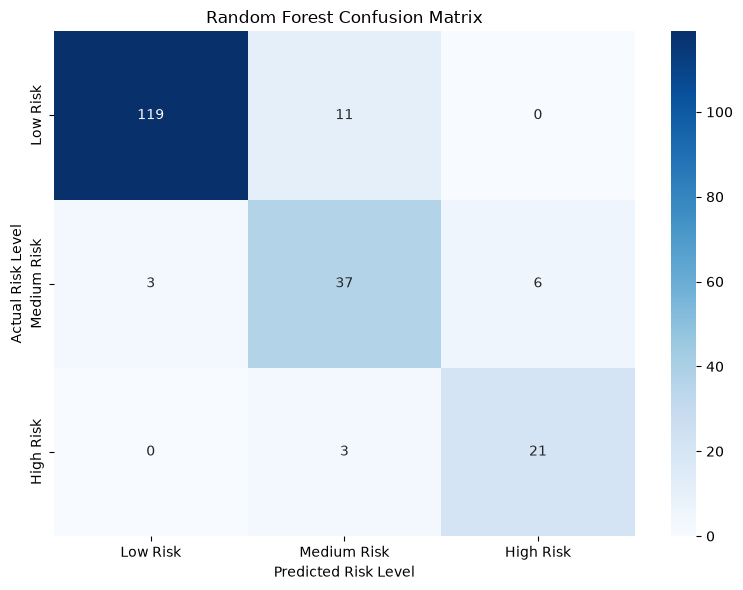

In [38]:
# Visualize the confusion matrix

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low Risk", "Medium Risk", "High Risk"],
    yticklabels=["Low Risk", "Medium Risk", "High Risk"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Risk Level")
plt.ylabel("Actual Risk Level")

plt.tight_layout()
plt.show()

### Feature Importance

Feature importance shows the relative contribution of each input variable to the Random Forest model's predictions. It helps explain which student characteristics the model relied on most when classifying academic risk.

In [39]:
# Calculate and display feature importance

feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

feature_importance["Importance"] = feature_importance["Importance"].round(4)

feature_importance

,Feature,Importance
0,Previous_CGPA,0.2879
1,Backlogs,0.2871
2,Attendance,0.0694
3,Study_Hours,0.0638
4,Internal_Marks,0.0513
5,LMS_Activity,0.0451
6,Commute_Time,0.0378
7,Assignment_Score,0.0354
8,Lab_Usage,0.0351
9,Library_Visits,0.0207


### Feature Importance Visualization

A horizontal bar chart is used to visualize the relative importance of the variables used by the Random Forest model for predicting student academic risk.

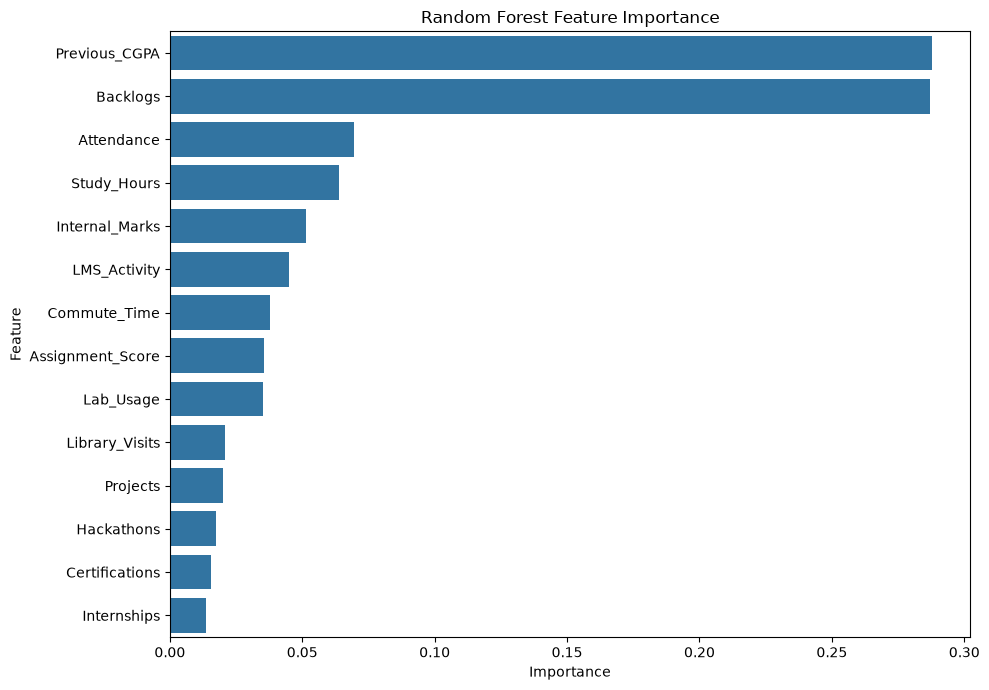

In [40]:
# Visualize feature importance

plt.figure(figsize=(10, 7))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

### Individual Student Risk Prediction

The trained Random Forest model is used to predict the academic risk level of a sample student based on the student's attendance, previous CGPA, academic performance, engagement, and other relevant features.

In [41]:
# Select one student from the test dataset

sample_student = X_test.iloc[[0]]

actual_risk = y_test.iloc[0]

predicted_risk = model.predict(sample_student)[0]

print("Individual Student Risk Prediction")
print("-" * 40)

print("Actual Risk Level   :", actual_risk)
print("Predicted Risk Level:", predicted_risk)

print("\nStudent Features:")
display(sample_student)

Individual Student Risk Prediction
----------------------------------------
Actual Risk Level   : Medium Risk
Predicted Risk Level: Medium Risk

Student Features:


,Attendance,Previous_CGPA,Internal_Marks,Assignment_Score,Study_Hours,LMS_Activity,Library_Visits,Lab_Usage,Certifications,Projects,Hackathons,Internships,Commute_Time,Backlogs
277,86.19,7.44,63.81,78.36,5.26,66.07,4,68.61,2,4,0,0,12.93,1


### Prediction Probability

The model provides a probability for each risk category. These probabilities show the model's estimated likelihood that a student belongs to the Low Risk, Medium Risk, or High Risk category.

In [42]:
# Calculate prediction probabilities for the sample student

probabilities = model.predict_proba(sample_student)[0]
classes = model.classes_

probability_df = pd.DataFrame({
    "Risk_Level": classes,
    "Probability": probabilities
})

probability_df["Probability"] = (
    probability_df["Probability"] * 100
).round(2)

probability_df

,Risk_Level,Probability
0,High Risk,8.71
1,Low Risk,21.80
2,Medium Risk,69.49


### Prediction Probability Visualization

A bar chart is used to visualize the model's predicted probability for each student risk category.

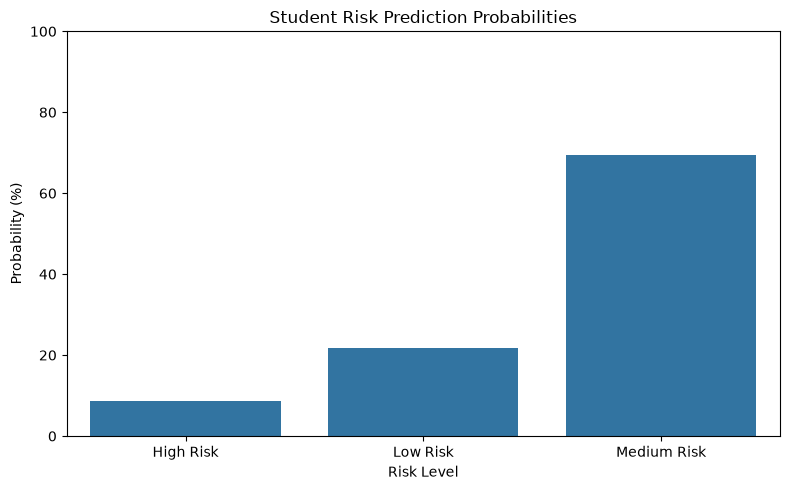

In [43]:
# Visualize prediction probabilities

plt.figure(figsize=(8, 5))

sns.barplot(
    data=probability_df,
    x="Risk_Level",
    y="Probability"
)

plt.title("Student Risk Prediction Probabilities")
plt.xlabel("Risk Level")
plt.ylabel("Probability (%)")

plt.ylim(0, 100)

plt.tight_layout()
plt.show()

## 4. Conclusion

This project demonstrates how Business Intelligence and Predictive Analytics can be combined to analyze student academic performance, learning engagement, campus resource usage, and academic risk.

### Key Findings

- The dataset contains **1,000 student records** and **21 variables**.
- Average Final CGPA is **7.33**.
- Average attendance is **80.25%**.
- **120 students** are classified as High Risk.
- Higher attendance is associated with higher average Final CGPA in this dataset.
- Higher LMS activity is also positively associated with Final CGPA.
- Students with more backlogs generally have lower average Final CGPA.
- Previous CGPA and Backlogs were the two most important features used by the Random Forest model.
- The Random Forest model achieved **88.50% accuracy** and **84.36% macro F1** on the 200-student test set.

### Business Value

The analysis can help an institution understand academic-performance patterns, monitor student engagement, identify groups that may require additional academic support, and use predictive analytics as an early-warning prototype.

### Important Limitation

This project uses a **synthetic dataset**. The relationships identified in the analysis are associations and should not be interpreted as proof of causation. The predictive model is a prototype and should be validated using appropriate real-world institutional data before being used for actual student decisions.